In [2]:
# ============================================================
# V2 run/update fine sweep CSV
# Fixed kT, fine density scan
# ============================================================

import time
import importlib
import numpy as np
import pandas as pd

import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Sweep_Helpers as sw
import md_Helpers.Logging_Helpers as lh

importlib.reload(sh)
importlib.reload(sw)
importlib.reload(lh)


# ============================================================
# Sweep settings
# ============================================================

n_fcc_cells = 30

# Fine density range
rho_min  = 0.700
rho_max  = 0.720
rho_step = 0.001

# Fixed temperature
kT_fixed = 0.800
kT_min = kT_fixed
kT_max = kT_fixed

# Important for fine scan
rho_decimals = 3
kT_decimals = 3

rho_values = sw.make_scan_values(
    rho_min,
    rho_max,
    rho_step,
    decimals=rho_decimals,
)

kT_values = np.array(
    [round(kT_fixed, kT_decimals)]
)

# Safety checks against accidental duplicate values from rounding
if len(np.unique(rho_values)) != len(rho_values):
    raise RuntimeError(
        "rho_values contains duplicate values. "
        "Increase rho_decimals or check rho_step."
    )

if len(np.unique(kT_values)) != len(kT_values):
    raise RuntimeError(
        "kT_values contains duplicate values. "
        "Increase kT_decimals or check kT settings."
    )

nsteps = 1_000_000
log_period = 1_000
seed = 1
phase_name = "randomization"

overwrite = False
overwrite_lattice = False
skip_completed_with_values = True


# ============================================================
# Summary CSV
# ============================================================

summary_path = sw.get_v2_summary_path(
    n_fcc_cells=n_fcc_cells,
    kT_min=kT_min,
    kT_max=kT_max,
    rho_min=rho_min,
    rho_max=rho_max,
    nsteps=nsteps,
)

df = sw.load_summary_csv(
    summary_path,
)

print("Summary CSV:")
print(summary_path)
print("Existing rows:", len(df))

print("\nrho_values:")
print(rho_values)

print("\nkT_values:")
print(kT_values)

print("\nExpected grid:")
print("Number of rho points:", len(rho_values))
print("Number of kT points:", len(kT_values))
print("Total simulations expected:", len(rho_values) * len(kT_values))


# ============================================================
# Run sweep
# ============================================================

total_runs = len(kT_values) * len(rho_values)
run_counter = 0

sweep_start = time.time()

for kT in kT_values:
    for rho in rho_values:
        run_counter += 1

        kT = round(float(kT), kT_decimals)
        rho = round(float(rho), rho_decimals)

        sweep_key = sw.make_v2_sweep_key(
            n_fcc_cells=n_fcc_cells,
            target_rho=rho,
            kT=kT,
            nsteps=nsteps,
            log_period=log_period,
            seed=seed,
            phase_name=phase_name,
        )

        # ========================================================
        # Expected file paths for this state
        # ========================================================

        expected_paths = lh.get_phase_paths(
            n_fcc_cells=n_fcc_cells,
            target_rho=rho,
            kT=kT,
            nsteps=nsteps,
            seed=seed,
            phase_name=phase_name,
        )

        expected_state_path = expected_paths["state_path"]
        expected_log_path = expected_paths["log_path"]

        state_exists = expected_state_path.exists()
        log_exists = expected_log_path.exists()
        files_exist = state_exists and log_exists

        # ========================================================
        # Print run information
        # ========================================================

        print("\n" + "=" * 80)
        print(f"Run {run_counter} / {total_runs}")
        print(f"n_fcc_cells = {n_fcc_cells}")
        print(f"N           = {4 * n_fcc_cells**3}")
        print(f"kT          = {kT:.3f}")
        print(f"rho         = {rho:.3f}")
        print(f"nsteps      = {nsteps:,}")
        print(f"log_period  = {log_period:,}")
        print(f"state exists: {state_exists}")
        print(f"log exists:   {log_exists}")
        print("=" * 80)

        # ========================================================
        # Skip only if CSV is complete AND files exist
        # ========================================================

        csv_completed = False

        if skip_completed_with_values and not overwrite:
            csv_completed = sw.already_completed_with_values(
                df=df,
                sweep_key=sweep_key,
            )

            if csv_completed and files_exist:
                print("Already completed with values in CSV and files exist. Skipping.")
                continue

            if csv_completed and not files_exist:
                print("CSV says completed, but one or more files are missing.")
                print("Re-running this state and updating the CSV.")
                print("Expected state:", expected_state_path)
                print("Expected log:  ", expected_log_path)

        run_start = time.time()

        row = {
            "sweep_key": sweep_key,
            "n_fcc_cells": n_fcc_cells,
            "N": 4 * n_fcc_cells**3,
            "kT": kT,
            "target_rho": rho,
            "nsteps": nsteps,
            "log_period": log_period,
            "seed": seed,
            "phase_name": phase_name,
            "status": "not_started",
        }

        try:
            result = sh.get_or_make_thermalized_state(
                n_fcc_cells=n_fcc_cells,
                target_rho=rho,
                kT=kT,
                nsteps=nsteps,
                log_period=log_period,
                seed=seed,
                phase_name=phase_name,
                overwrite=overwrite,
                overwrite_lattice=overwrite_lattice,
            )

            run_time_seconds = time.time() - run_start

            row.update(
                sw.summarize_completed_result(
                    result=result,
                    run_time_seconds=run_time_seconds,
                    n_last=100,
                )
            )

            print("Completed")
            print("Created new:", row["created_new"])
            print("Phase separated:", row["phase_separated"])
            print("State file:", row["state_path"])
            print("Log file:  ", row["log_path"])
            print(f"Runtime:   {run_time_seconds:.2f} seconds")

            print("Final last-100 stats:")
            print(f"  pressure mean = {row['pressure_mean_last100']}")
            print(f"  pressure std  = {row['pressure_std_last100']}")
            print(f"  PE/N mean     = {row['PE_per_particle_mean_last100']}")
            print(f"  PE/N std      = {row['PE_per_particle_std_last100']}")
            print(f"  KE/N mean     = {row['KE_per_particle_mean_last100']}")
            print(f"  KE/N std      = {row['KE_per_particle_std_last100']}")

        except Exception as e:
            run_time_seconds = time.time() - run_start

            row.update(
                sw.make_failed_row_update(
                    error=e,
                    run_time_seconds=run_time_seconds,
                )
            )

            print("FAILED")
            print(e)
            print(f"Runtime: {run_time_seconds:.2f} seconds")

        # ========================================================
        # Update CSV after every attempted run
        # ========================================================

        df = sw.update_summary_row(
            df=df,
            row=row,
        )

        df.to_csv(
            summary_path,
            index=False,
        )

        print("Updated summary CSV:")
        print(summary_path)


# ============================================================
# Final summary
# ============================================================

sweep_time_seconds = time.time() - sweep_start

df.to_csv(
    summary_path,
    index=False,
)

print("\n" + "=" * 80)
print("Sweep finished")
print(f"Total grid points:    {total_runs}")
print(f"Rows in CSV:          {len(df)}")

if "status" in df.columns:
    print(f"Completed rows:       {(df['status'] == 'completed').sum()}")
    print(f"Failed rows:          {(df['status'] == 'failed').sum()}")

print(f"Total wall time:      {sweep_time_seconds:.2f} seconds")
print("Summary file:")
print(summary_path)
print("=" * 80)

df

Summary CSV:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Sweep_Summaries/sweep_summary_ncells_30_kT_0.80_0.80_rho_0.70_0.72_nsteps_1000000.csv
Existing rows: 21

rho_values:
[0.7   0.701 0.702 0.703 0.704 0.705 0.706 0.707 0.708 0.709 0.71  0.711
 0.712 0.713 0.714 0.715 0.716 0.717 0.718 0.719 0.72 ]

kT_values:
[0.8]

Expected grid:
Number of rho points: 21
Number of kT points: 1
Total simulations expected: 21

Run 1 / 21
n_fcc_cells = 30
N           = 108000
kT          = 0.800
rho         = 0.700
nsteps      = 1,000,000
log_period  = 1,000
state exists: True
log exists:   True
Already completed with values in CSV and files exist. Skipping.

Run 2 / 21
n_fcc_cells = 30
N           = 108000
kT          = 0.800
rho         = 0.701
nsteps      = 1,000,000
log_period  = 1,000
state exists: True
log exists:   True
Already completed with values in CSV and files exist. Skipping.

Run 3 / 21
n_fcc_cells = 30
N           = 108000
kT          = 0.800
rho         =

,sweep_key,n_fcc_cells,N,kT,target_rho,nsteps,log_period,seed,phase_name,status,...,kinetic_temperature_mean_last100,kinetic_temperature_std_last100,n_values_used,first_timestep_used,last_timestep_used,final_timestep,starting_state_path,run_time_seconds,error,traceback
0,n_cells_30_rho_0.700_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.700,1000000,1000,1,randomization,completed,...,0.800164,0.002135,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,0.088075,NaN,NaN
1,n_cells_30_rho_0.701_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.701,1000000,1000,1,randomization,completed,...,0.800158,0.002099,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,505.145301,NaN,NaN
2,n_cells_30_rho_0.702_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.702,1000000,1000,1,randomization,completed,...,0.800144,0.002092,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,517.211851,NaN,NaN
3,n_cells_30_rho_0.703_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.703,1000000,1000,1,randomization,completed,...,0.800171,0.002094,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,516.288408,NaN,NaN
4,n_cells_30_rho_0.704_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.704,1000000,1000,1,randomization,completed,...,0.800115,0.002100,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,507.477761,NaN,NaN
5,n_cells_30_rho_0.705_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.705,1000000,1000,1,randomization,completed,...,0.800152,0.002097,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,510.085710,NaN,NaN
6,n_cells_30_rho_0.706_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.706,1000000,1000,1,randomization,completed,...,0.800132,0.002111,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,508.960339,NaN,NaN
7,n_cells_30_rho_0.707_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.707,1000000,1000,1,randomization,completed,...,0.800125,0.002061,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,519.768919,NaN,NaN
8,n_cells_30_rho_0.708_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.708,1000000,1000,1,randomization,completed,...,0.800165,0.002106,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,508.806025,NaN,NaN
9,n_cells_30_rho_0.709_kT_0.800_nsteps_1000000_l...,30,108000,0.8,0.709,1000000,1000,1,randomization,completed,...,0.800151,0.002082,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,511.617272,NaN,NaN


rho values:
[0.7   0.701 0.702 0.703 0.704 0.705 0.706 0.707 0.708 0.709 0.71  0.711
 0.712 0.713 0.714 0.715 0.716 0.717 0.718 0.719 0.72 ]
kT values:
[0.8]
Number of rho points: 21
Number of kT points: 1
Total simulations expected: 21
Expected sweep CSV:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Sweep_Summaries/sweep_summary_ncells_30_kT_0.80_0.80_rho_0.70_0.72_nsteps_1000000.csv
CSV exists: True
Rows in CSV: 21


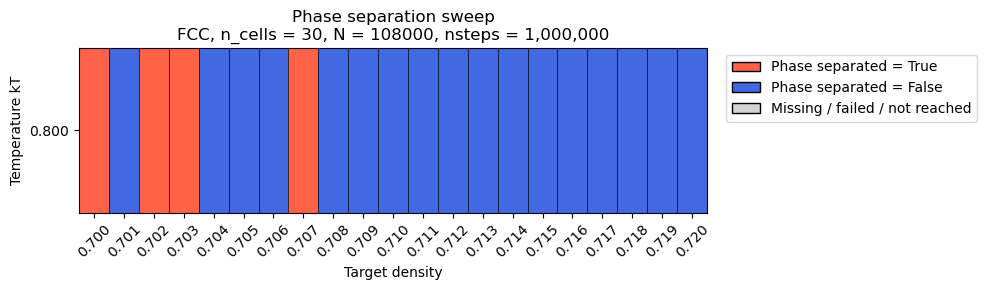

Sweep CSV summary
CSV file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/Sweep_Summaries/sweep_summary_ncells_30_kT_0.80_0.80_rho_0.70_0.72_nsteps_1000000.csv
n_fcc_cells:                  30
N:                            108000
Total grid points:            21
Completed rows:               21
Failed rows:                  0
Missing / failed / not reached: 0
Phase separated True:         4
Phase separated False:        17


,kT,target_rho,sweep_key,n_fcc_cells,N,nsteps,log_period,seed,phase_name,status,...,n_values_used,first_timestep_used,last_timestep_used,final_timestep,starting_state_path,run_time_seconds,error,traceback,phase_separated_clean,phase_code
0,0.8,0.700,n_cells_30_rho_0.700_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,0.088075,NaN,NaN,True,1
1,0.8,0.701,n_cells_30_rho_0.701_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,505.145301,NaN,NaN,False,0
2,0.8,0.702,n_cells_30_rho_0.702_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,517.211851,NaN,NaN,True,1
3,0.8,0.703,n_cells_30_rho_0.703_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,516.288408,NaN,NaN,True,1
4,0.8,0.704,n_cells_30_rho_0.704_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,507.477761,NaN,NaN,False,0
5,0.8,0.705,n_cells_30_rho_0.705_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,510.085710,NaN,NaN,False,0
6,0.8,0.706,n_cells_30_rho_0.706_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,508.960339,NaN,NaN,False,0
7,0.8,0.707,n_cells_30_rho_0.707_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,519.768919,NaN,NaN,True,1
8,0.8,0.708,n_cells_30_rho_0.708_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,508.806025,NaN,NaN,False,0
9,0.8,0.709,n_cells_30_rho_0.709_kT_0.800_nsteps_1000000_l...,30,108000,1000000,1000,1,randomization,completed,...,100,901000,1000000,1000000,/exp/e961/data/MDsims-data/pnichols/Simple_Lat...,511.617272,NaN,NaN,False,0


In [3]:
# ============================================================
# V2 phase separation heat map from sweep CSV
# ============================================================

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

import md_Helpers.Sweep_Helpers as sw

importlib.reload(sw)


# ============================================================
# Sweep settings
# Must match the sweep CSV you made
# ============================================================

n_fcc_cells = 30

rho_min  = 0.700
rho_max  = 0.720
rho_step = 0.001

kT_fixed = 0.800

kT_min = kT_fixed
kT_max = kT_fixed

nsteps = 1_000_000

rho_decimals = 3
kT_decimals = 3

# ============================================================
# Rebuild expected sweep grid
# ============================================================

rho_values = sw.make_scan_values(
    rho_min,
    rho_max,
    rho_step,
    decimals=rho_decimals,
)

# For one-temperature scans, make this explicit.
# This avoids any weirdness from using a nonzero kT_step when min=max.
kT_values = np.array(
    [round(kT_fixed, kT_decimals)]
)

print("rho values:")
print(rho_values)

print("kT values:")
print(kT_values)

print("Number of rho points:", len(rho_values))
print("Number of kT points:", len(kT_values))
print("Total simulations expected:", len(rho_values) * len(kT_values))



# ============================================================
# CSV path
# ============================================================

summary_path = sw.get_v2_summary_path(
    n_fcc_cells=n_fcc_cells,
    kT_min=kT_min,
    kT_max=kT_max,
    rho_min=rho_min,
    rho_max=rho_max,
    nsteps=nsteps,
)

print("Expected sweep CSV:")
print(summary_path)
print("CSV exists:", summary_path.exists())

if summary_path.exists():
    df = pd.read_csv(summary_path)
else:
    print("CSV does not exist yet. Making an empty dataframe for plotting.")
    print("This means the heat map will show all points as missing/grey.")

    df = pd.DataFrame(
        columns=[
            "kT",
            "target_rho",
            "status",
            "phase_separated",
        ]
    )

print("Rows in CSV:", len(df))


# ============================================================
# Clean phase_separated column
# ============================================================

df["phase_separated_clean"] = df["phase_separated"].apply(
    sw.clean_bool_value
)


# ============================================================
# Build full expected grid, including not-yet-run points
# ============================================================

full_grid = sw.build_full_grid(
    kT_values=kT_values,
    rho_values=rho_values,
)

# Keep only the most recent row for each point, in case duplicates exist
df_sorted = df.sort_values(
    [
        "kT",
        "target_rho",
    ]
).copy()

df_unique = (
    df_sorted
    .drop_duplicates(
        subset=[
            "kT",
            "target_rho",
        ],
        keep="last",
    )
    .copy()
)

plot_df = full_grid.merge(
    df_unique,
    on=[
        "kT",
        "target_rho",
    ],
    how="left",
)


# ============================================================
# Encode values for heat map
#
# -1 = missing, failed, incomplete, or no usable phase flag
#  0 = completed and phase_separated is False
#  1 = completed and phase_separated is True
# ============================================================

def encode_phase_row(row):
    if row.get("status") != "completed":
        return -1

    if row.get("phase_separated_clean") is True:
        return 1

    if row.get("phase_separated_clean") is False:
        return 0

    return -1


plot_df["phase_code"] = plot_df.apply(
    encode_phase_row,
    axis=1,
)


# ============================================================
# Pivot into heat map grid
# ============================================================

heatmap_grid = plot_df.pivot(
    index="kT",
    columns="target_rho",
    values="phase_code",
)

# Lower temperatures at the bottom of the plot
heatmap_grid = heatmap_grid.sort_index(
    ascending=True,
)


# ============================================================
# Plot heat map
# ============================================================

plt.figure(figsize=(10, 3))

# Colors:
# grey  = missing / failed / not reached yet
# blue  = phase_separated False
# red   = phase_separated True
cmap = ListedColormap(
    [
        "lightgray",
        "royalblue",
        "tomato",
    ]
)

bounds = [
    -1.5,
    -0.5,
    0.5,
    1.5,
]

norm = BoundaryNorm(
    bounds,
    cmap.N,
)

plt.imshow(
    heatmap_grid.values,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
)

plt.xticks(
    ticks=np.arange(len(heatmap_grid.columns)),
    labels=[f"{rho:.3f}" for rho in heatmap_grid.columns],
    rotation=45,
)

plt.yticks(
    ticks=np.arange(len(heatmap_grid.index)),
    labels=[f"{kT:.3f}" for kT in heatmap_grid.index],
)

plt.xlabel("Target density")
plt.ylabel("Temperature kT")

plt.title(
    f"Phase separation sweep\n"
    f"FCC, n_cells = {n_fcc_cells}, N = {4 * n_fcc_cells**3}, "
    f"nsteps = {nsteps:,}"
)


# ============================================================
# Add grid lines between boxes
# ============================================================

ax = plt.gca()

ax.set_xticks(
    np.arange(
        -0.5,
        len(heatmap_grid.columns),
        1,
    ),
    minor=True,
)

ax.set_yticks(
    np.arange(
        -0.5,
        len(heatmap_grid.index),
        1,
    ),
    minor=True,
)

ax.grid(
    which="minor",
    color="black",
    linestyle="-",
    linewidth=0.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)


# ============================================================
# Add legend
# ============================================================

legend_handles = [
    Patch(
        facecolor="tomato",
        edgecolor="black",
        label="Phase separated = True",
    ),
    Patch(
        facecolor="royalblue",
        edgecolor="black",
        label="Phase separated = False",
    ),
    Patch(
        facecolor="lightgray",
        edgecolor="black",
        label="Missing / failed / not reached",
    ),
]

plt.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)

plt.tight_layout()
plt.show()


# ============================================================
# Print quick progress summary
# ============================================================

n_total = len(plot_df)
n_completed = (plot_df["status"] == "completed").sum()
n_failed = (plot_df["status"] == "failed").sum()
n_missing_or_unreached = (plot_df["phase_code"] == -1).sum()
n_phase_true = (plot_df["phase_code"] == 1).sum()
n_phase_false = (plot_df["phase_code"] == 0).sum()

print("=" * 80)
print("Sweep CSV summary")
print("=" * 80)
print("CSV file:", summary_path)
print(f"n_fcc_cells:                  {n_fcc_cells}")
print(f"N:                            {4 * n_fcc_cells**3}")
print(f"Total grid points:            {n_total}")
print(f"Completed rows:               {n_completed}")
print(f"Failed rows:                  {n_failed}")
print(f"Missing / failed / not reached: {n_missing_or_unreached}")
print(f"Phase separated True:         {n_phase_true}")
print(f"Phase separated False:        {n_phase_false}")
print("=" * 80)


# ============================================================
# Show table used for plotting
# ============================================================

plot_df.sort_values(
    [
        "kT",
        "target_rho",
    ]
)